
Image restoration experiment
---------------------------------------------
GPU device: Tesla T4
Image size: 736 x 736
Noise level: 0.08
---------------------------------------------
Sequential filtering started...
Sequential filtering completed

CUDA filtering started...
CUDA filtering completed

Statistics
---------------------------------------------
CPU execution: 1.606545 sec
GPU execution: 0.000326 sec
Acceleration: 4929.29x
Identical output: True

Quality metrics
---------------------------------------------
PSNR noisy image: 14.800
PSNR CPU result: 26.885
PSNR GPU result: 26.885


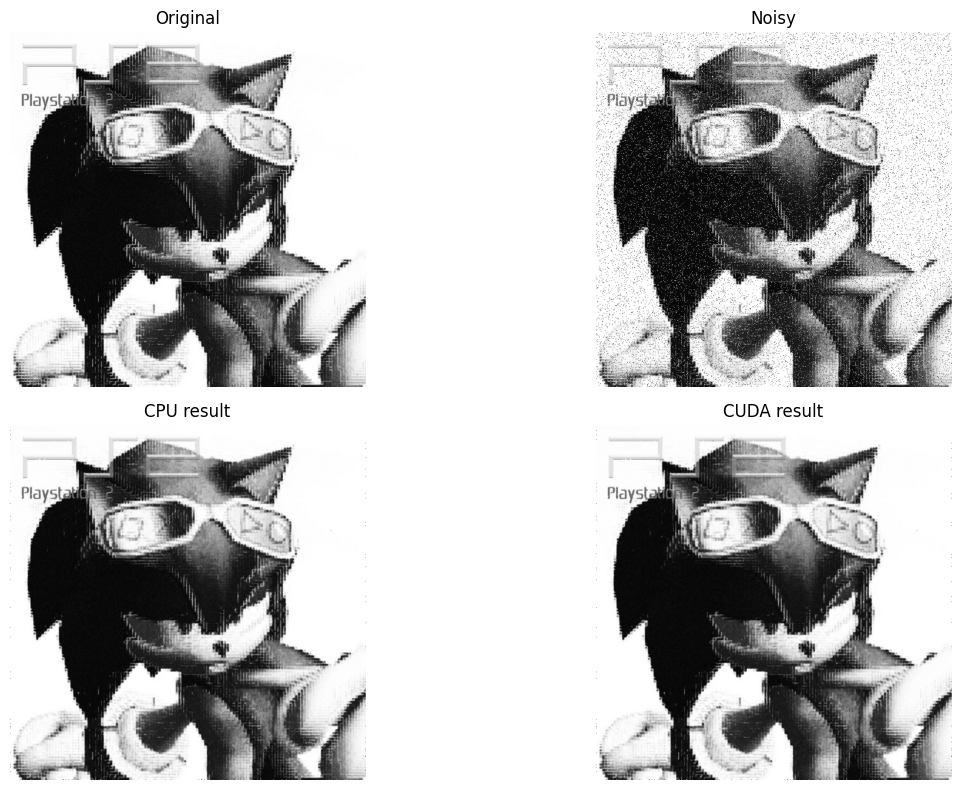

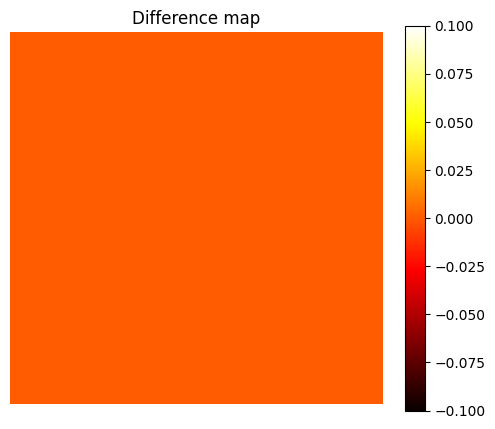

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from numba import cuda


# ============================================================
# CUDA median filter
# ============================================================

@cuda.jit
def median_cuda(source, result, h, w):

    y, x = cuda.grid(2)

    if y >= h or x >= w:
        return

    if x == 0 or y == 0 or x == w - 1 or y == h - 1:
        result[y, x] = source[y, x]
        return

    values = cuda.local.array(9, dtype=np.uint8)

    index = 0

    for dy in range(-1, 2):
        for dx in range(-1, 2):

            values[index] = source[y + dy, x + dx]
            index += 1

    # bubble sort

    for i in range(9):

        for j in range(0, 8 - i):

            if values[j] > values[j + 1]:

                temp = values[j]
                values[j] = values[j + 1]
                values[j + 1] = temp

    result[y, x] = values[4]


# ============================================================
# image loading
# ============================================================

def load_grayscale(path):

    image = Image.open(path).convert("L")

    return np.array(image, dtype=np.uint8)


# ============================================================
# salt & pepper noise
# ============================================================

def apply_impulse_noise(image, amount=0.08):

    damaged = image.copy()

    random_values = np.random.random(image.shape)

    black = random_values < amount / 2
    white = random_values > 1 - amount / 2

    damaged[black] = 0
    damaged[white] = 255

    return damaged


# ============================================================
# cpu filtering
# ============================================================

def median_cpu(image):

    h, w = image.shape

    filtered = image.copy()

    for y in range(1, h - 1):

        for x in range(1, w - 1):

            fragment = []

            for dy in range(-1, 2):

                for dx in range(-1, 2):

                    fragment.append(image[y + dy, x + dx])

            fragment.sort()

            filtered[y, x] = fragment[4]

    return filtered


# ============================================================
# gpu filtering
# ============================================================

def median_gpu(image):

    h, w = image.shape

    output = np.zeros_like(image)

    d_source = cuda.to_device(image)
    d_output = cuda.to_device(output)

    threads = (16, 16)

    blocks = (
        (h + threads[0] - 1) // threads[0],
        (w + threads[1] - 1) // threads[1]
    )

    # warmup

    median_cuda[blocks, threads](
        d_source,
        d_output,
        h,
        w
    )

    cuda.synchronize()

    start = time.time()

    median_cuda[blocks, threads](
        d_source,
        d_output,
        h,
        w
    )

    cuda.synchronize()

    elapsed = time.time() - start

    output = d_output.copy_to_host()

    return output, elapsed


# ============================================================
# metrics
# ============================================================

def calculate_mse(original, processed):

    diff = original.astype(np.float32) - processed.astype(np.float32)

    return np.mean(diff * diff)


def calculate_psnr(original, processed):

    error = calculate_mse(original, processed)

    if error == 0:
        return 100

    return 20 * np.log10(255.0 / np.sqrt(error))


# ============================================================
# visualization
# ============================================================

def draw_results(original, noisy, cpu_img, gpu_img):

    fig = plt.figure(figsize=(14, 8))

    ax1 = fig.add_subplot(2, 2, 1)
    ax1.set_title("Original")
    ax1.imshow(original, cmap="gray")
    ax1.axis("off")

    ax2 = fig.add_subplot(2, 2, 2)
    ax2.set_title("Noisy")
    ax2.imshow(noisy, cmap="gray")
    ax2.axis("off")

    ax3 = fig.add_subplot(2, 2, 3)
    ax3.set_title("CPU result")
    ax3.imshow(cpu_img, cmap="gray")
    ax3.axis("off")

    ax4 = fig.add_subplot(2, 2, 4)
    ax4.set_title("CUDA result")
    ax4.imshow(gpu_img, cmap="gray")
    ax4.axis("off")

    plt.tight_layout()
    plt.show()


def draw_difference(cpu_img, gpu_img):

    delta = np.abs(
        cpu_img.astype(np.int16) -
        gpu_img.astype(np.int16)
    )

    plt.figure(figsize=(6, 5))

    plt.title("Difference map")

    plt.imshow(delta, cmap="hot")

    plt.colorbar()

    plt.axis("off")

    plt.show()


# ============================================================
# experiment
# ============================================================

def run():

    if not cuda.is_available():
        raise RuntimeError("CUDA device not found")

    device = cuda.get_current_device()

    print()
    print("Image restoration experiment")
    print("-" * 45)

    print(f"GPU device: {device.name}")

    image = load_grayscale("123.jpg")

    h, w = image.shape

    print(f"Image size: {w} x {h}")

    noise_level = 0.08

    print(f"Noise level: {noise_level}")

    print("-" * 45)

    corrupted = apply_impulse_noise(image, noise_level)

    print("Sequential filtering started...")

    cpu_start = time.time()

    cpu_result = median_cpu(corrupted)

    cpu_time = time.time() - cpu_start

    print("Sequential filtering completed")

    print()

    print("CUDA filtering started...")

    gpu_result, gpu_time = median_gpu(corrupted)

    print("CUDA filtering completed")

    print()

    print("Statistics")
    print("-" * 45)

    print(f"CPU execution: {cpu_time:.6f} sec")

    print(f"GPU execution: {gpu_time:.6f} sec")

    print(f"Acceleration: {cpu_time / gpu_time:.2f}x")

    identical = np.array_equal(cpu_result, gpu_result)

    print(f"Identical output: {identical}")

    print()

    print("Quality metrics")
    print("-" * 45)

    print(
        f"PSNR noisy image: "
        f"{calculate_psnr(image, corrupted):.3f}"
    )

    print(
        f"PSNR CPU result: "
        f"{calculate_psnr(image, cpu_result):.3f}"
    )

    print(
        f"PSNR GPU result: "
        f"{calculate_psnr(image, gpu_result):.3f}"
    )

    draw_results(
        image,
        corrupted,
        cpu_result,
        gpu_result
    )

    draw_difference(
        cpu_result,
        gpu_result
    )


# ============================================================
# start
# ============================================================

run()